## [FoL](https://arxiv.org/abs/2504.09881) (Focus on Local) & [FoL++](https://arxiv.org/abs/2604.22390) (Region Matters)

This notebook demonstrates keypoint matching guided by **Discriminative Region Guidance** with **optional geometric verification** using FoL.

Given a **source image** and a **target image**, **FoL** finds the same local features between them and visualizes the matching results.

---

For questions, please contact: **shunpengchen@bupt.edu.cn**

## 🚀 Setup

We load the pretrained FoL model via Torch Hub.

In [8]:
import torch

# Check for CUDA availability early to support the matching script
if not torch.cuda.is_available():
    raise RuntimeError(
        'This demo relies on FoL_visualize_match.py, which requires GPU acceleration. '
        'In Colab, please go to: Runtime > Change runtime type and select GPU.'
    )

device = "cuda"

# Load pretrained FoL model from Torch Hub
model = torch.hub.load('chenshunpeng/FoL', 'FoL' , backbone='vitl', pretrained=True, trust_repo=True)
model = model.eval().to(device)

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


## 🛄 Clone the FoL repository so we can use its example images


In [ ]:
!git clone https://github.com/chenshunpeng/FoL.git
%cd FoL

## 📍 Example :


Query image: image/match_pair/query.jpg
Database image: image/match_pair/database.jpg
Size of patch tokens: torch.Size([7921, 128])
Number of matched point pairs (before RANSAC): 29
Number of matched point pairs (after RANSAC): 21


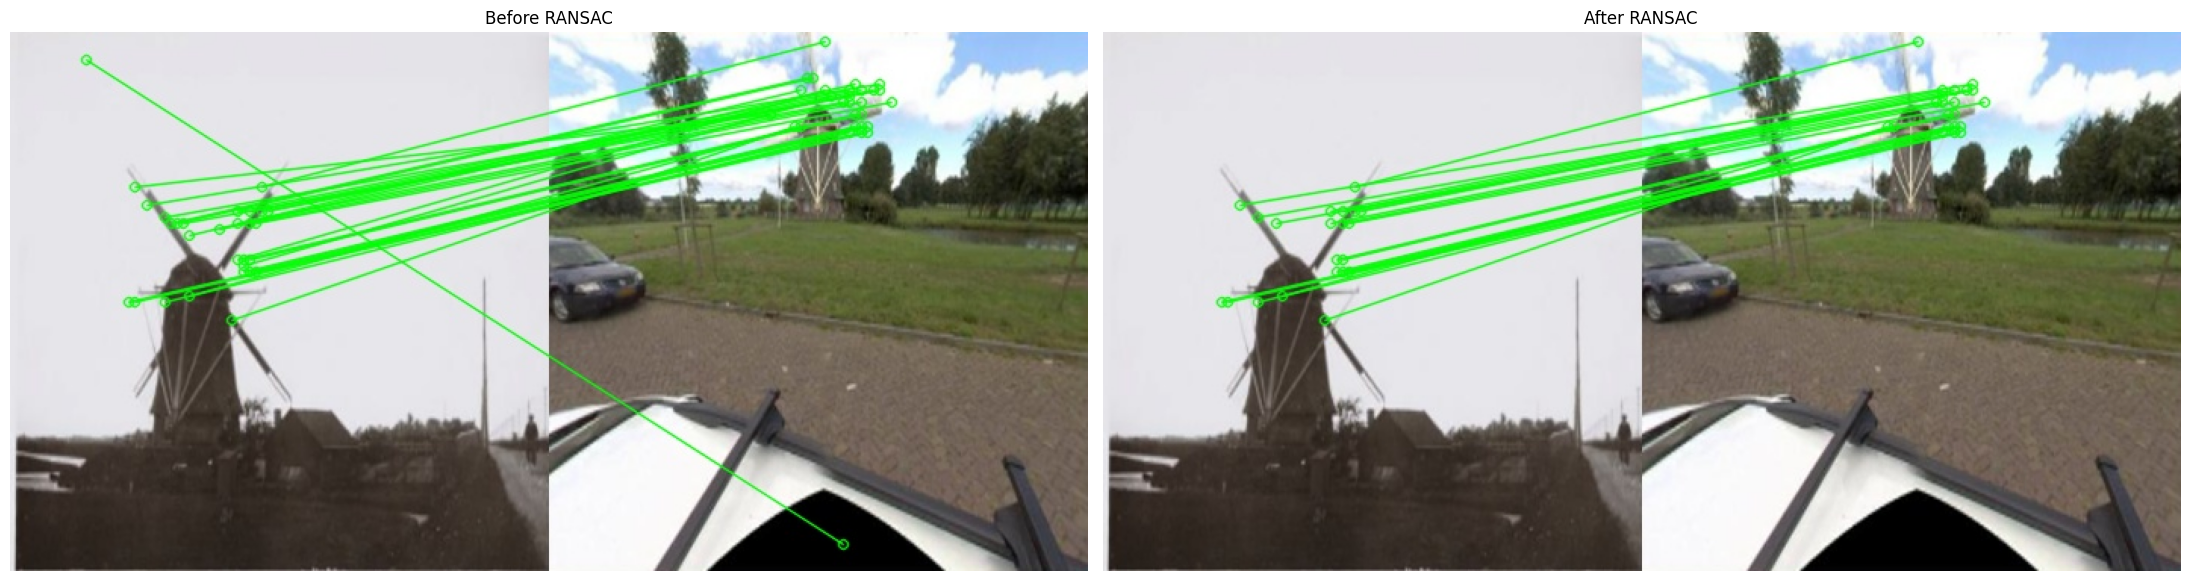

In [9]:
import cv2
import os
import sys
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from pathlib import Path
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt


repo_dir = Path('/content/FoL')
os.chdir(repo_dir)
sys.path.insert(0, str(repo_dir))
from visualize_pairs import FoL_visualize_match as fol_visualize

# Upload images (use the images provided by the project by default)
USE_UPLOAD = False  # Change to True to upload your own image pair.

if USE_UPLOAD:
    from google.colab import files

    uploaded = files.upload()
    image_paths = list(uploaded.keys())
    assert len(image_paths) >= 2, 'Please upload at least two images.'

    query_path = image_paths[0]
    database_path = image_paths[1]
else:
    query_path = 'image/match_pair/query.jpg'
    database_path = 'image/match_pair/database.jpg'

print('Query image:', query_path)
print('Database image:', database_path)

# Run demo
transform = fol_visualize.input_transform()
fol_visualize.display_and_match_features(
    model,
    query_path,
    database_path,
    transform,
)

raw_path = str(Path(fol_visualize.OUTPUT_DIR) / 'foL_visualize.jpg')
ransac_path = str(Path(fol_visualize.OUTPUT_DIR) / 'foL_visualize_ransac.jpg')

## Display results
raw_img = Image.open(raw_path)
ransac_img = Image.open(ransac_path)

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

axes[0].imshow(raw_img)
axes[0].set_title("Before RANSAC")
axes[0].axis("off")

axes[1].imshow(ransac_img)
axes[1].set_title("After RANSAC")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## ✏️ Try FoL on your own images

You can now run FoL on your own data by configuring the following parameters:

- `query_path`: Path to your source/query image.
- `database_path`: Path to your target/database image.
- `similarity_threshold`: Threshold for cosine similarity filtering. Lower values yield more matching lines, while higher values ensure stricter feature filtering.

## 📌 Citation

If you find this repo useful for your research, please consider citing our original conference paper ([FoL](https://arxiv.org/abs/2504.09881)) and the extended journal version ([FoL++](https://arxiv.org/abs/2604.22390)):

```bibtex
@inproceedings{FoL,
  title={Focus on Local: Finding Reliable Discriminative Regions for Visual Place Recognition},
  author={Wang, Changwei and Chen, Shunpeng and Song, Yukun and Xu, Rongtao and Zhang, Zherui and Zhang, Jiguang and Yang, Haoran and Zhang, Yu and Fu, Kexue and Du, Shide and others},
  booktitle={Proceedings of the AAAI Conference on Artificial Intelligence},
  volume={39},
  number={7},
  pages={7536--7544},
  year={2025}
}

@article{FoL++,
  title={Region Matters: Efficient and Reliable Region-Aware Visual Place Recognition},
  author={Chen, Shunpeng and Song, Yukun and Wang, Changwei and Xu, Rongtao and Fu, Kexue and Gao, Longxiang and Guo, Li and Wang, Ruisheng and Xu, Shibiao},
  journal={arXiv preprint arXiv:2604.22390},
  year={2026}
}